In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

In [2]:
soy_raw = pd.read_csv('soy_raw.csv')
sm = pd.read_csv('sm.csv')
vod = pd.read_csv('vod.csv')

In [3]:
# Process the daily soil moisture and VOD data into a 4-month mean, 90th percentile, 10th percentile and standard deviation.

sm_data = pd.DataFrame({
    'sm_mean': sm.mean(axis=1),
    'sm_q5': sm.quantile(0.05, axis=1),
    'sm_q95': sm.quantile(0.95, axis=1),
    'sm_std': sm.std(axis=1)
})

vod_data = pd.DataFrame({
    'vod_mean': vod.mean(axis=1),
    'vod_q5': vod.quantile(0.05,axis=1),
    'vod_q95': vod.quantile(0.95,axis=1),
    'vod_std': vod.std(axis=1)
})

sm_data.head()

,sm_mean,sm_q5,sm_q95,sm_std
0,0.160216,0.091869,0.238131,0.044583
1,0.197299,0.138234,0.236725,0.032614
2,0.172573,0.073943,0.233433,0.045325
3,0.220197,0.152329,0.265495,0.035747
4,0.179592,0.063475,0.265588,0.055550


In [4]:
# Combine all values into one final dataframe

soy_data = pd.concat([soy_raw, sm_data, vod_data],axis=1)
soy_data.head()

,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul,sm_mean,sm_q5,sm_q95,sm_std,vod_mean,vod_q5,vod_q95,vod_std
0,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132,0.160216,0.091869,0.238131,0.044583,0.393141,0.316100,0.494518,0.054919
1,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022,0.197299,0.138234,0.236725,0.032614,0.279009,0.225902,0.321308,0.032779
2,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778,0.172573,0.073943,0.233433,0.045325,0.227040,0.167861,0.288062,0.038181
3,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999,0.220197,0.152329,0.265495,0.035747,0.317403,0.262077,0.391281,0.038965
4,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548,0.179592,0.063475,0.265588,0.055550,0.206323,0.136790,0.282111,0.047684


<Axes: >

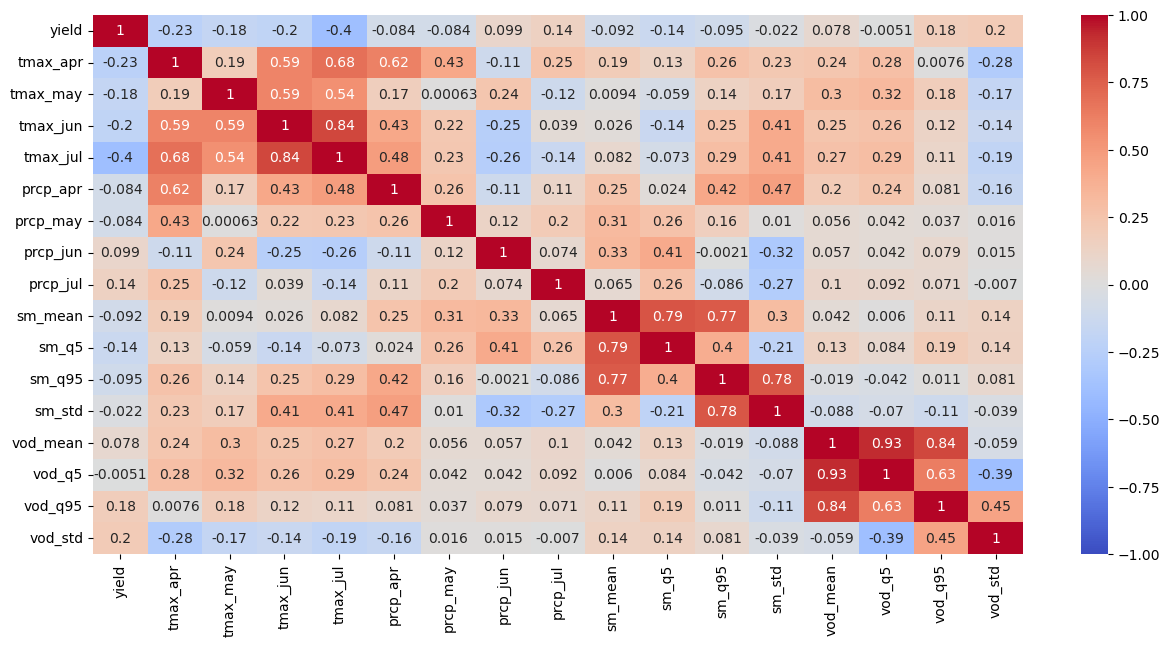

In [13]:
# Create a correlation matrix to determine features.

fig,axes = plt.subplots(1,1,figsize=(15,7))
soy_corr_mat = soy_data.corr(numeric_only=True)
sb.heatmap(soy_corr_mat, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes)

<Axes: >

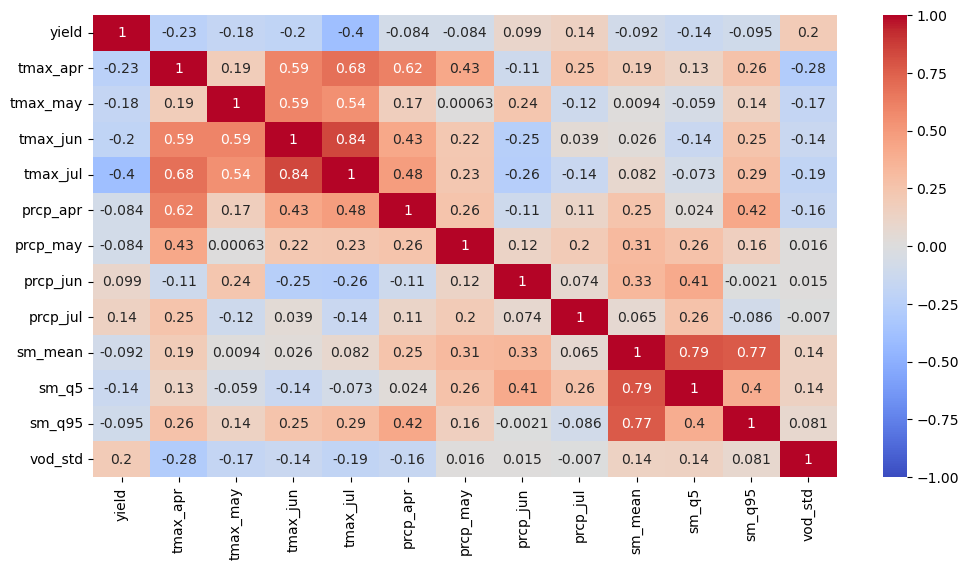

In [10]:
# Create a second correlation matrix with only the features and the label for legibility.

fig,axes2 = plt.subplots(1,1,figsize=(12,6))
soy_new = soy_data.drop(columns=["sm_std","vod_mean","vod_q5","vod_q95"])
soy_corr_mat_3 = soy_new.corr(numeric_only=True)
sb.heatmap(soy_corr_mat_3, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes2)